In [197]:
import numpy as np
import matplotlib.pyplot as plt

## Exercícios Práticos para o Método dos Mínimos Quadrados

In [198]:
def plot(xi, yi, x_aprox, y_aprox, grf):
    plt.plot(xi, yi, "ro", "MarkerSize", 4)
    plt.plot(x_aprox, y_aprox, grf)
    plt.legend(["Pontos Tabelados", "Polinômio"])

In [199]:
def minimos_quadrados(xi, yi, m):
    n = len(xi) #numero de pontos
    mn = m + 1 # numero dos coeficientes dos polinomios
    u = np.zeros((n, mn))

    for i in range(mn):
        u[:, i] = xi[:] ** i

    N = 100
    x = np.linspace(xi[0], xi[n - 1], N)

    G = np.zeros((mn, mn))
    b = np.zeros(mn)

    for i in range(mn):
        b[i] = np.sum(u[:, i] * yi)

        for j in range(mn):
            G[i, j] = sum(u[:, i] * u[:, j])

    #resolucao do sistema linear
    a = np.linalg.inv(G) @ b

    #Erro de truncamento
    nos = u @ a
    Q = np.sum((yi[:] - nos) ** 2)
    print(f"Erro de Truncamento: {Q}")

    P = np.zeros((N, mn))

    for i in range(mn):
        P[:, i] = x[:] ** i

    y_aprox = P @ a

    return x, y_aprox, a


Tome como exercício o exemplo visto na apostila para o caso discreto do método dos mínimos quadrados.

a) Obtenha de forma numérica a equação da reta que melhor aproxima os pontos tabelados de $f(x)$ e o erro de truncamento desta aproximação.

b) Faça o mesmo considerando agora um polinômio de 3º grau.

c)
Plote as soluções obtidas para este exemplo:
- reta  
- polinômio de 2º grau (feito em aula)  
- polinômio de 3º grau  

em um único gráfico para fins comparativos.

d) Obtenha, para cada solução obtida, uma aproximação para $f(0.2)$.

In [200]:
xi = np.array([-1.0, 0.0, 1.0, 2.0])
yi = np.array([0.0, -1.0, 0.0, 7.0])

In [201]:
#a)
x, y, a1 = minimos_quadrados(xi, yi, 1)
print(f"P1 = {a1[0]:.2f} + {a1[1]:.2f}x")

Erro de Truncamento: 16.8
P1 = 0.40 + 2.20x


In [202]:
#b)
x, y, a3 = minimos_quadrados(xi, yi, 3)
print(f"P3 = {a3[0]:.2f} + {a3[1]:.2f}x + {a3[2]:.2f}x² + {a3[3]:.2f}x³")

Erro de Truncamento: 5.806016262426647e-28
P3 = -1.00 + -0.67x + 1.00x² + 0.67x³


Erro de Truncamento: 16.8
Erro de Truncamento: 0.8000000000000002
Erro de Truncamento: 5.806016262426647e-28


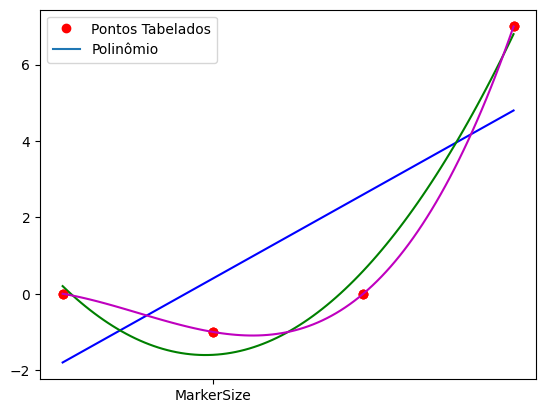

In [203]:
#c)
x1, y1, a1 = minimos_quadrados(xi, yi, 1)
x2, y2, a2 = minimos_quadrados(xi, yi, 2)
x3, y3, a3 = minimos_quadrados(xi, yi, 3)

plot(xi, yi, x1, y1, "b-")
plot(xi, yi, x2, y2, "g-")
plot(xi, yi, x3, y3, "m")

plt.show()


In [204]:
#d)
def f(x, polinomio):
    y = 0
    for i in range(len(polinomio)):
        y += polinomio[i] * x ** i
    return y

y1 = f(0.2, a1)
y2 = f(0.2, a2)
y3 = f(0.2, a3)

print(f"f1(0.2) = {y1:.2f}")
print(f"f2(0.2) = {y2:.2f}")
print(f"f3(0.2) = {y3:.2f}")

f1(0.2) = 0.84
f2(0.2) = -1.48
f3(0.2) = -1.09


Considere a função dada pela tabela:

| x   | -1 | -0.5 | 1 | 1.5 | 2 | 2.5 | 3 | 3.5 | 4 | 6 |
|-----|----|------|---|-----|---|-----|---|-----|---|---|
| y   | -4 | 2    | 6 | 3.2 | 1 | 12  | 6 | 7.6 | 4.8 | 9 |

a) Obtenha de forma numérica a expressão para os polinômios de grau:
- 1  
- 2  
- 3  

que aproximam esses dados pelo método dos mínimos quadrados.

b) Plote os resultados obtidos em um único gráfico.

c) Usando os resultados, aproxime um valor para $f(5)$ para cada polinômio.

In [205]:
#a)
xi = np.array([-1.0, -0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 6.0])
yi = np.array([-4.0, 2.0, 6.0, 3.2, 1.0, 12.0, 6.0, 7.6, 4.8, 9.0])

x1, y1, a1 = minimos_quadrados(xi, yi, 1)
x2, y2, a2 = minimos_quadrados(xi, yi, 2)
x3, y3, a3 = minimos_quadrados(xi, yi, 3)

print("\n", end="")
print(f"P1 = {a1[0]:.2f} + {a[1]:.2f}x")
print(f"P2 = {a2[0]:.2f} + {a2[1]:.2f}x + {a2[2]:.2f}x²")
print(f"P3 = {a3[0]:.2f} + {a3[1]:.2f}x + {a3[2]:.2f}x² + {a3[3]:.2f}x³")

Erro de Truncamento: 94.91717171717171
Erro de Truncamento: 81.59541218637993
Erro de Truncamento: 75.14347650199537

P1 = 1.49 + 0.20x
P2 = 1.15 + 2.62x + -0.24x²
P3 = 2.02 + 3.57x + -1.02x² + 0.10x³


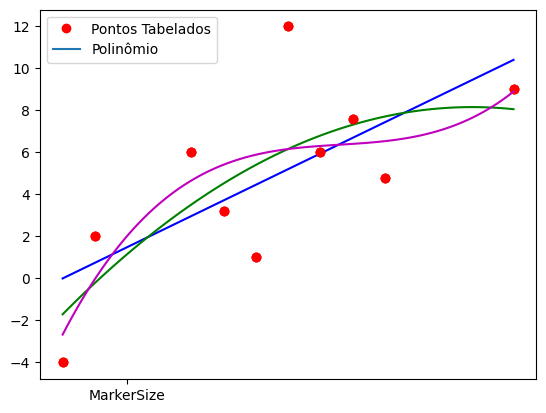

In [206]:
plot(xi, yi, x1, y1, "b-")
plot(xi, yi, x2, y2, "g-")
plot(xi, yi, x3, y3, "m")

In [207]:
#c)
y1 = f(0.5, a1)
y2 = f(0.5, a2)
y3 = f(0.5, a3)

print(f"f1(5) = {y1:.2f}")
print(f"f2(5) = {y2:.2f}")
print(f"f3(5) = {y3:.2f}")

f1(5) = 2.23
f2(5) = 2.40
f3(5) = 3.56
